In [2]:
import numpy as np
import pandas as pd

# Steps



### 0. Preprocess + EDA + Feature Selection

### 1. Extract input and output cols

### 2. Scale the values

### 3. Train test split

### 4. Train the model

### 5. Evaluate the model/model selection

### 6. Deploy the model

In [9]:
df=pd.read_csv("placements.csv")
df

,Student_ID,CGPA,IQ,Placement
0,1,6.8,123,1
1,2,5.9,106,0
2,3,5.3,121,0
3,4,7.4,132,1
4,5,5.8,142,0
...,...,...,...,...
95,96,4.3,200,0
96,97,4.4,42,0
97,98,6.7,182,1
98,99,6.3,103,1


In [10]:
## removing useless column - "student_id"
df=df.drop("Student_ID", axis=1)
df

,CGPA,IQ,Placement
0,6.8,123,1
1,5.9,106,0
2,5.3,121,0
3,7.4,132,1
4,5.8,142,0
...,...,...,...
95,4.3,200,0
96,4.4,42,0
97,6.7,182,1
98,6.3,103,1


In [11]:
import matplotlib.pyplot as plt

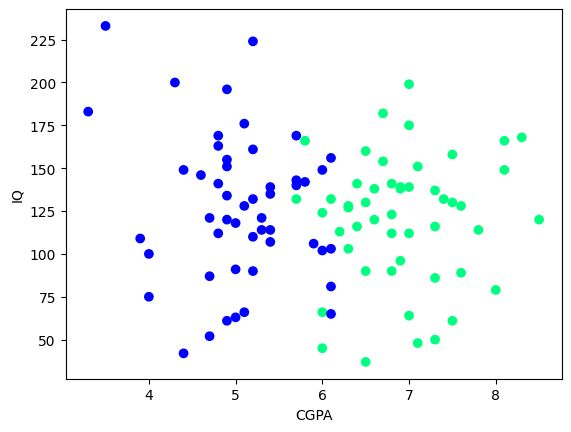

In [16]:
plt.scatter(
    df["CGPA"],
    df["IQ"],
    c=df["Placement"],
    cmap="winter"
)

plt.xlabel("CGPA")
plt.ylabel("IQ")
plt.show()

In [ ]:
x=df.drop("Placement", axis=1)
x
y=df.drop(["CGPA",  "IQ"], axis=1)
y
y = y.squeeze() # y is expected to be series (single column since output is singular but inputs are multiple)

## first we train test split and then we scale the values

In [50]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test =train_test_split(x,y,test_size=0.2)

In [51]:
print(x_train)
print(x_test)
print(y_train)
print(y_test)

    CGPA   IQ
11   6.9  138
71   6.1  132
83   7.5  130
42   7.6   89
54   6.4  141
..   ...  ...
79   6.5   90
32   7.0  139
36   5.7  140
48   6.6  138
4    5.8  142

[80 rows x 2 columns]
    CGPA   IQ
82   6.5   37
40   4.9  134
73   4.9   61
19   5.2  132
84   5.7  169
53   8.3  168
3    7.4  132
95   4.3  200
17   3.3  183
22   4.9  120
97   6.7  182
68   4.0   75
46   5.3  114
10   6.0   45
94   4.7   52
30   7.6  128
85   5.8  166
24   4.7  121
96   4.4   42
5    7.1   48
11    1
71    1
83    1
42    1
54    1
     ..
79    1
32    1
36    0
48    1
4     0
Name: Placement, Length: 80, dtype: int64
82    1
40    0
73    0
19    0
84    0
53    1
3     1
95    0
17    0
22    0
97    1
68    0
46    0
10    1
94    0
30    1
85    1
24    0
96    0
5     1
Name: Placement, dtype: int64


In [52]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [53]:
x_train=scaler.fit_transform(x_train)
x_train
x_test=scaler.fit_transform(x_test)
x_test

array([[ 0.70883925, -1.49439483],
       [-0.53066107,  0.35335914],
       [-0.53066107, -1.03721859],
       [-0.29825476,  0.31526112],
       [ 0.08908909,  1.02007448],
       [ 2.10327711,  1.00102547],
       [ 1.40605818,  0.31526112],
       [-0.9954737 ,  1.61059379],
       [-1.7701614 ,  1.28676062],
       [-0.53066107,  0.086673  ],
       [ 0.86377679,  1.26771161],
       [-1.22788001, -0.77053245],
       [-0.22078599, -0.02762106],
       [ 0.3214954 , -1.34200275],
       [-0.68559861, -1.20865968],
       [ 1.56099572,  0.23906508],
       [ 0.16655786,  0.96292745],
       [-0.68559861,  0.10572201],
       [-0.91800492, -1.39914978],
       [ 1.17365187, -1.28485572]])

In [54]:
from sklearn.linear_model import LogisticRegression
clf=LogisticRegression()

In [55]:
# model training
clf.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [56]:
y_predict=(clf.predict(x_test))

In [59]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_predict)

0.95

In [58]:
import sys
!{sys.executable} -m pip install mlxtend


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip


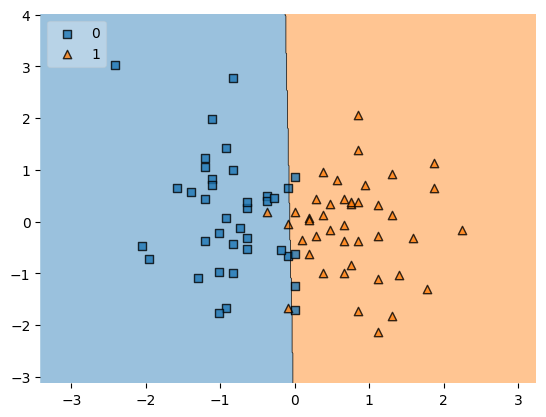

In [60]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(
    x_train,
    y_train.values,
    clf=clf,
    legend=2
)

plt.show()

In [61]:
import pickle

In [63]:

pickle.dump(clf, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [64]:
print(clf.coef_)
print(clf.intercept_)

[[3.13682713 0.04518456]]
[0.20509995]
